In [2]:
import funcs
import os
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

In [39]:
path_x_train = 'banco2/teste/imgs'
# path_y_train = 'banco2/teste/labels'

x_train, nomes_train = funcs.banco(path_x_train, resolution=(256,256), grayscale= True, nomes=True)
# y_train, labels_train = funcs.banco(path_y_train, resolution=(256,256), grayscale= True, nomes=True)

# print(f'Tamanho x_train: {x_train.shape}, y_train: {y_train.shape}')
print(nomes_train)
# print(labels_train)

['I-2452-250527-132713.jpg', 'I-6186-240507-135245.jpg']


In [49]:
""" Modifica o banco de dados"""
dict_x_train, x_train_m = funcs.modificacoes1(x_train, 
             nomes_train, 
             original = True, 
             brilho = 1.7,
             escura= 0.5,
             rotacao=[-15,15],
             nitidez=[0.5, 2.0],
             manchas_pretas={
                 "qtd": (2, 3),
                 "raio_rel": (0.08, 0.1),
                 "intensidade": (0.4,1),
                 "blur_ksize": 9,
                "y_range": (40,150),
                "x_range": (0,150),
                "manter_dentro": True,
             },
)
# dict_y_train = dict(zip(labels_train, y_train))

print(f'Quantidade de chaves em dict_x_train: {dict_x_train.keys()}')
print(f'Quantidade de valores em dict_x_train: {len(dict_x_train.values())}')


# y_train_m, y_train_keys = funcs.modificacoes2(dict_y_train, dict_x_train.keys())

# print(f'imagens modificadas em y_train_m: {len(y_train_m)}')
# print(f'y_train_keys: {y_train_keys}')

Quantidade de chaves em dict_x_train: dict_keys(['I-2452-250527-132713_origi_0.jpg', 'I-2452-250527-132713_luz_0.jpg', 'I-2452-250527-132713_dark_0.jpg', 'I-2452-250527-132713_rot_4_0.jpg', 'I-2452-250527-132713_ndz_0.jpg', 'I-2452-250527-132713_mp_0.jpg'])
Quantidade de valores em dict_x_train: 6


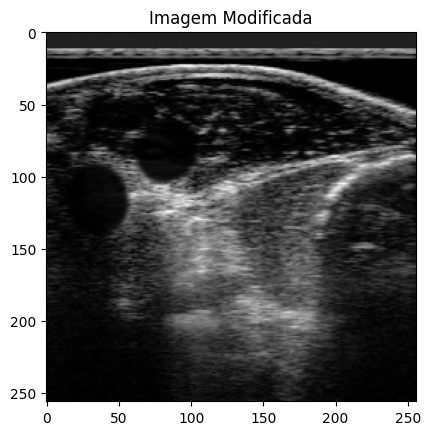

In [50]:
img = x_train_m[5]
plt.imshow(img, cmap='gray')
plt.title('Imagem Modificada')
plt.axis('on')
plt.show()

In [90]:
def _carregar_imagens(paths, largura, altura, canais):
    imagens = []
    grayscale = canais == 1

    for caminho in paths:
        img = Image.open(caminho)
        print(img.size)

        esquerda = largura * 0.19
        superior = altura * 0.188
        direita = largura * 1.8
        inferior = altura *1.7
        img = img.crop((esquerda, superior, direita, inferior))
        print(f'Imagem recortada: {img.size}')
        img = img.resize((largura, altura))

        if grayscale:
            img = img.convert("L")
        else:
            img = img.convert("RGB")

        arr = np.asarray(img, dtype=np.float32) / 255.0
        if grayscale:
            arr = np.expand_dims(arr, axis=-1)

        imagens.append(arr)

    return np.asarray(imagens, dtype=np.float32)

(640, 480)
Imagem recortada: (412, 387)
(1, 256, 256, 1)


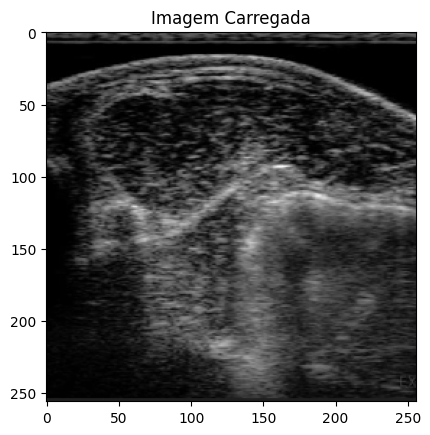

In [92]:
img = _carregar_imagens(['banco2/teste/imgs/I-6186-240507-135245.jpg'], 256, 256, 1)
print(img.shape)
plt.imshow(img[0], cmap='gray')
plt.title('Imagem Carregada')
plt.axis('on')
plt.show()
    